In [1]:
# =============================================================================
# BIBLIOTHEKEN UND SETUP
# =============================================================================

# Standardbibliotheken
import os

# Datenverarbeitung
import numpy as np
import pandas as pd

# Visualisierung
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Globales Design für Grafiken setzen (empfohlen für Publikationen)
sns.set_theme(style="whitegrid")

### **Metadata**

In [2]:
# =========================================================
# 1. SETUP UND DATEIPFADE
# =========================================================
input_file = 'total_featuretable.csv'
out_dir_data = '/Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate'
out_dir_result = '/Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate'
os.makedirs(out_dir_data, exist_ok=True)
os.makedirs(out_dir_data, exist_ok=True)
# =========================================================
# 2. DICTIONARIES FÜR METADATEN
# =========================================================
mode_mapping = {
    'mode1': 'T2-TSE',
    'mode2': 'SWI',
    'mode3': 'T1-FLD2',
    'mode4': 'T2-TIRM',
    'mode5': 'PD-TSE Dixon',
    'mode6': 'T1-VIBE',
    'mode7': 'T1-TSE'
}

color_mapping = {
    'color1': 'The Colossal Go Extreme Waterproof Mascara',
    'color2': 'Dynamic Union Black',
    'color3': 'Intenze Gen-Z Lining Red Light',
    'color4': 'Epic Ink Liner Glitz Waterproof',
    'color5': 'Contour Pencil Eyeliner Waterproof',
    'color6': 'The Colossal Waterproof Mascara',
    'color7': 'Waterproof Lipliner Rosy Sand',
    'color8': 'Silberglitzer Lidschatten',
    'color9': '203 Chocolat Brown',
    'color10': '304 Deep Black',
    'color11': '103_Orange',
    'color12': 'KVM_True_Black',
    'color13': 'KVM_Blue_Sky',
    'color14': 'Dongyun_Tattoo_Ink_red',
    'color15': 'Dongyun_Tattoo_Ink_green',
    'blank': 'Blank'
}

material_metadata = {
    'color1': {
        'Kategorie_Pigment': 'Kosmetik',
        'Hersteller': 'Maybelline New York',
        'Produktname': 'The Colossal Go Extreme! Volum’ Waterproof Mascara',
        'Inhaltsstoffe': 'Ultramarines, Mica, CI 77891 (Titanium Dioxide), CI 75470 (Carmine), CI 77288 (Chromium Oxide Greens), CI 77289 (Chromium Hydroxide Green), CI 77742 (Manganese Violet), CI 77510 (Ferric Ferrocyanide)'
    },
    'color2': {
        'Kategorie_Pigment': 'Tattoo',
        'Hersteller': 'Dynamic Color Co. (USA)',
        'Produktname': 'Dynamic UNB (Union Black)',
        'Inhaltsstoffe': 'Aqua, Carbon Black (CI 77266), Glycerin, Benzyl Alcohol'
    },
    'color3': {
        'Kategorie_Pigment': 'Tattoo',
        'Hersteller': 'Intenze Products INC. (USA)',
        'Produktname': 'Intenze Gen-Z Lining Red Light',
        'Inhaltsstoffe': 'Aqua, Hamamelis Virginiana Extract, CI 56110, Glycerin, Ethanol, Ammonium Acrylates Copolymer'
    },
    'color4': {
        'Kategorie_Pigment': 'Kosmetik',
        'Hersteller': 'NYX Professional Makeup',
        'Produktname': 'Epic Ink Liner Glitz Waterproof',
        'Inhaltsstoffe': 'Aqua, Butylene Glycol, CI 77510 (Ferric Ammonium Ferrocyanide), Styrene/Acrylates Copolymer, Calcium Aluminum Borosilicate, Glycerin, Acrylates Copolymer, Tin Oxide, CI 77891 (Titanium Dioxide)'
    },
    'color5': {
        'Kategorie_Pigment': 'Kosmetik',
        'Hersteller': 'Sephora Collection',
        'Produktname': '12H Contour Pencil Eyeliner Waterproof',
        'Inhaltsstoffe': 'Aqua, CI 77499 (Iron Oxides), Alcohol Denat., Styrene/Acrylates/Ammonium Methacrylate Copolymer, Silica'
    },
    'color6': {
        'Kategorie_Pigment': 'Kosmetik',
        'Hersteller': 'Maybelline New York',
        'Produktname': 'The Colossal Waterproof Mascara',
        'Inhaltsstoffe': 'Isododecane, Cera Microcristallina, C8-9 Isoparaffin, Cera Alba, Iron Oxides, Titanium Dioxide, Mica, Chromium Oxide Greens'
    },
    'color7': {
        'Kategorie_Pigment': 'Kosmetik',
        'Hersteller': 'Flormar Cosmetics (Türkei)',
        'Produktname': 'Waterproof Lipliner Rosy Sand',
        'Inhaltsstoffe': 'Hydrogenated Polyisobutene, Polyethylene, Synthetic Wax, Iron Oxides (CI 77491, CI 77492, CI 77499), Titanium Dioxide (CI 77891)'
    },
    'color8': {
        'Kategorie_Pigment': 'Kosmetik',
        'Hersteller': 'Wolfera Cosmetics (Deutschland)',
        'Produktname': 'Silberglitzer-Lidschatten (Wolfera Palette)',
        'Inhaltsstoffe': 'Mica, Synthetic Fluorphlogopite, Calcium Aluminum Borosilicate, Tin Oxide, Silica, Iron Oxides (CI 77491, CI 77492, CI 77499), Titanium Dioxide (CI 77891)'
    },
    'color9': {
        'Kategorie_Pigment': 'PMU',
        'Hersteller': 'Swiss Color (Schweiz)',
        'Produktname': '203 Chocolat Brown',
        'Inhaltsstoffe': 'Aqua, Propylene Glycol, Iron Oxides (CI 77491, CI 77492, CI 77499), Silica, PVP, Sodium Polyphosphate'
    },
    'color10': {
        'Kategorie_Pigment': 'PMU',
        'Hersteller': 'Swiss Color (Schweiz)',
        'Produktname': '304 Deep Black',
        'Inhaltsstoffe': 'Aqua, Propylene Glycol, Carbon Black (CI 77266), 1,2-Hexanediol, PVP, Simethicone'
    },
    'color11': {
        'Kategorie_Pigment': 'PMU',
        'Hersteller': 'Swiss Color (Schweiz)',
        'Produktname': '103 Orange',
        'Inhaltsstoffe': 'Aqua, Propylene Glycol, Iron Oxides (CI 77266), Silica, PVP'
    }
}

# =========================================================
# 3. DATEN EINLESEN & METADATEN ZUWEISEN
# =========================================================
df = pd.read_csv(input_file)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.rename(columns={'in cm': 'Measurement_Type'}, inplace=True)
id_col = 'Measurement_Type'
sample_columns = [col for col in df.columns if col != id_col]

metadata_records = []
for col in sample_columns:
    clean_col = col.replace(' ', '')
    parts = clean_col.split('_')

    if len(parts) >= 5:
        raw_field   = parts[0]
        raw_subject = parts[1]
        raw_mode    = parts[2]
        raw_color   = parts[3]
        raw_rep     = parts[4]

        feldstaerke = '1.5 Tesla' if raw_field == '15T' else ('3.0 Tesla' if raw_field == '30T' else raw_field)

        actual_mode = mode_mapping.get(raw_mode, raw_mode)
        actual_color = color_mapping.get(raw_color, raw_color)

        # 1. Bestimme Objekt (Proband vs Phantom)
        if 'phantom' in clean_col.lower():
            objekt = 'Phantom'
        elif 'proband' in clean_col.lower():
            objekt = 'Proband'
        else:
            objekt = raw_subject.capitalize()

        # 2. Bestimme Träger (Wimpern vs Kunsthaut) anhand des Spaltennamens
        if 'lashes' in clean_col.lower():
            traeger = 'Wimpern'
        elif 'kunsthaut' in clean_col.lower():
            traeger = 'Kunsthaut'
        else:
            traeger = 'k.A.'

        # 3. Bestimme Replikat (1, 2 oder 3) anhand des Spaltennamens!
        if 'rep1' in clean_col.lower():
            replikat_wert = 1
        elif 'rep2' in clean_col.lower():
            replikat_wert = 2
        elif 'rep3' in clean_col.lower():
            replikat_wert = 3
        else:
            replikat_wert = raw_rep # Fallback auf die Spaltentrennung, falls nichts gefunden wird

        # 4. Bestimme Pigmentart
        if raw_color in ['color1', 'color4', 'color5', 'color6', 'color7', 'color8']:
            pigment_type = "Kosmetik"
        elif raw_color in ['color9', 'color10', 'color11']:
            pigment_type = "PMU"
        elif raw_color in ['color2', 'color3', 'color12', 'color13', 'color14', 'color15']:
            pigment_type = "Tattoo"
        elif 'blank' in raw_color.lower():
            pigment_type = "Blank"
        else:
            # Better fallback: try to get it from your material_metadata dict
            pigment_type = mat_info.get('Kategorie_Pigment', 'k.A.')


        # 5. Hole die neuen Material-Metadaten für die jeweilige Farbe
        mat_info = material_metadata.get(raw_color, {})

        metadata_records.append({
            'Sample_ID': col,
            'Feldstaerke': feldstaerke,
            'Objekt': objekt,
            'Traeger': traeger,
            'Mode': actual_mode,
            'Farbe_ID': actual_color,
            'Replikat': replikat_wert,
            'Kategorie_Pigment': pigment_type,
            'Hersteller': mat_info.get('Hersteller', 'k.A.'),
            'Produktname': mat_info.get('Produktname', 'k.A.'),
            'Inhaltsstoffe': mat_info.get('Inhaltsstoffe', 'k.A.')
        })

metadata_df = pd.DataFrame(metadata_records)

# Ausgabe speichern
metadata_df.to_csv(os.path.join(out_dir_data, "metadata.csv"), index=False)

print("Pipeline erfolgreich: Daten geladen, bereinigt und alle Metadaten exportiert.")

Pipeline erfolgreich: Daten geladen, bereinigt und alle Metadaten exportiert.


### **Data Preparation**

In [3]:
# =============================================================================
# DATEN-TRANSFORMATION UND BERECHNUNG DER ARTEFAKTFLÄCHE
# =============================================================================
# 1. Transponieren: Zeilen zu Spalten machen
df_eval = pd.DataFrame(df.T, columns=df.index)

# 2. Erste Zeile als Header setzen und Datenbereich bereinigen
df_eval.columns = df_eval.iloc[0]
df_eval = df_eval.drop(df_eval.index[0])
df_eval.columns.name = None

# 3. Datentypen konvertieren & Artefaktfläche berechnen
# Hinweis: Das Leerzeichen in 'A_Tiefe ' wurde hier explizit berücksichtigt/bereinigt
df_eval['A_Breite'] = pd.to_numeric(df_eval['A_Breite'], errors='coerce')
df_eval['A_Tiefe']  = pd.to_numeric(df_eval['A_Tiefe '], errors='coerce')

# Hauptmetrik für die statistische Auswertung
df_eval['Artefakt_flaeche'] = df_eval['A_Breite'] * df_eval['A_Tiefe']

# 4. Sample-IDs extrahieren (alle Spalten außer 'Measurement_Type')
df_eval['Sample_ID'] = [col for col in df.columns if col != 'Measurement_Type']

# Index zurücksetzen für eine saubere Tabelle
df_eval.reset_index(drop=True, inplace=True)

In [4]:
df_plot = df_eval[['Sample_ID','Artefakt_flaeche']].copy()

metadata_df['Sample_ID'] = metadata_df['Sample_ID'].astype(str).str.strip()
df_plot['Sample_ID'] = df_plot['Sample_ID'].astype(str).str.strip()
merged_df = pd.merge(metadata_df, df_plot, on='Sample_ID', how='left')

### **Mean and Standard Deviation per Group**

In [5]:
# =============================================================================
# STATISTISCHE ZUSAMMENFASSUNG UND EXPORT
# =============================================================================

# 1. Definition der Gruppierungsvariablen
# Diese Spalten bilden die Grundlage für den Vergleich der Messreihen
group_cols = [
    'Feldstaerke', 'Traeger', 'Objekt', 'Mode',
    'Farbe_ID', 'Kategorie_Pigment', 'Hersteller', 'Produktname'
]

# 2. Aggregation: Berechnung von Mittelwert (Mean) und Standardabweichung (SD)
# .reset_index() sorgt dafür, dass die gruppierten Spalten erhalten bleiben
df_summary = merged_df.groupby(group_cols)['Artefakt_flaeche'].agg(['mean', 'std']).reset_index()

# 3. Spaltennamen für die Publikation optimieren
df_summary = df_summary.rename(columns={
    'mean': 'Artefakt_flaeche_Mean',
    'std': 'Artefakt_flaeche_SD'
})

# 4. Export der Ergebnisse
df_summary.to_csv(
    os.path.join(out_dir_data, 'df_summary.csv'),
    index=False,
    encoding="utf-8-sig" # Sorgt für korrekte Darstellung von Umlauten in Excel
)

# Kurze Vorschau der berechneten Tabelle
print(f"Zusammenfassung exportiert nach: {os.path.join(out_dir_data, 'df_summary.csv')}")
df_summary.head()

Zusammenfassung exportiert nach: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/df_summary.csv


,Feldstaerke,Traeger,Objekt,Mode,Farbe_ID,Kategorie_Pigment,Hersteller,Produktname,Artefakt_flaeche_Mean,Artefakt_flaeche_SD
0,1.5 Tesla,Kunsthaut,Phantom,PD-TSE Dixon,103_Orange,PMU,Swiss Color (Schweiz),103 Orange,0.0000,0.000000
1,1.5 Tesla,Kunsthaut,Phantom,PD-TSE Dixon,203 Chocolat Brown,PMU,Swiss Color (Schweiz),203 Chocolat Brown,0.0000,0.000000
2,1.5 Tesla,Kunsthaut,Phantom,PD-TSE Dixon,304 Deep Black,PMU,Swiss Color (Schweiz),304 Deep Black,0.0000,0.000000
3,1.5 Tesla,Kunsthaut,Phantom,PD-TSE Dixon,Blank,Blank,k.A.,k.A.,0.0000,0.000000
4,1.5 Tesla,Kunsthaut,Phantom,PD-TSE Dixon,Contour Pencil Eyeliner Waterproof,Kosmetik,Sephora Collection,12H Contour Pencil Eyeliner Waterproof,0.3303,0.051704


### **Plot erstellen**

In [6]:
# =============================================================================
# KONFIGURATION DER VISUALISIERUNG
# =============================================================================
# Fehlende Werte (NaN) in Artefaktfläche als 0 behandeln
df_summary['Artefakt_flaeche_Mean'] = df_summary['Artefakt_flaeche_Mean'].fillna(0)

# 2. Globale Plot-Parameter (Matplotlib rcParams)
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'axes.grid': False
})

# 3. Farbpalette definieren
colors = {
    '1.5T': '#4DBBD5',      # Hellblau
    '3.0T': '#E64B35',      # Rot/Orange
    'Phantom': '#00A087',    # Grün
    'Proband': '#3C5488',    # Dunkelblau
    'Kunsthaut': '#8491B4',  # Blaugrau
    'Wimpern': '#7E6148',    # Braun
    'Artifact': '#E64B35',   # Rot
    'No_Artifact': '#E0E0E0' # Hellgrau
}


# Natur-Farben
sequence_colors = ['#2E8B57', '#4682B4', '#CD853F', '#DAA520', '#DDA0DD', '#708090', '#8B4513']

# Feste Farbzuordnung für jede Sequenz erstellen (damit in Plot 4 und 5 die Farben gleich sind)
unique_modes = df_summary['Mode'].dropna().unique()
color_map = {mode: sequence_colors[i % len(sequence_colors)] for i, mode in enumerate(unique_modes)}

# 4. Hilfsfunktion für Achsen-Styling
def style_axes(ax):
    """
    Entfernt obere und rechte Rahmenlinien und stellt sicher, dass
    die linke und untere Achse deutlich sichtbar sind.
    """
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(0.8)
# =============================================================================
# Outlier definieren
# =============================================================================
def get_outliers(df, cat_col, val_col, hue_col=None):
    groups = [cat_col] if hue_col is None else [cat_col, hue_col]
    outliers_list = []
    for name, group in df.groupby(groups):
        Q1 = group[val_col].quantile(0.25)
        Q3 = group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask = (group[val_col] < lower) | (group[val_col] > upper)
        outliers_list.append(group[mask])
    return pd.concat(outliers_list) if outliers_list else pd.DataFrame(columns=df.columns)

# =============================================================================


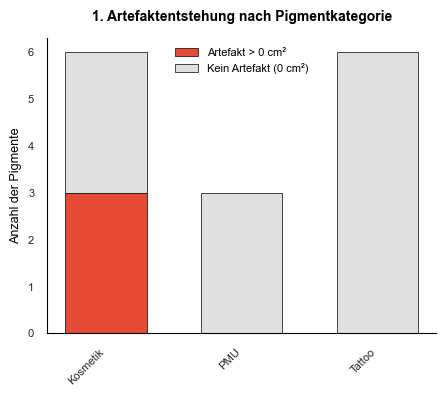

=== DATEN FÜR ABBILDUNG 1 (KATEGORIEN) ===
Has_Artifact       False  True 
Kategorie_Pigment              
Kosmetik               3      3
PMU                    3      0
Tattoo                 6      0

Die Daten wurden auch hier gespeichert: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/1_Kategorien_Vergleich_Daten.csv


In [7]:
# =============================================================================
# VISUALISIERUNG 1: ARTEFAKTENTSTEHUNG & TABELLEN-OUTPUT
# =============================================================================

# 1. Daten gruppieren und Filter anwenden
df_pigments = df_summary.groupby(['Kategorie_Pigment', 'Farbe_ID'])['Artefakt_flaeche_Mean'].max().reset_index()

# Filter "Blank" und "k.A." konsequent herausfiltern
df_pigments = df_pigments[~df_pigments['Kategorie_Pigment'].isin(['Blank', 'k.A.'])]
df_pigments = df_pigments[df_pigments['Farbe_ID'] != 'Blank']

# 2. Artefakt-Bedingung (> 0)
df_pigments['Has_Artifact'] = df_pigments['Artefakt_flaeche_Mean'] > 0

# 3. Zählen der Kategorien für den Stacked Plot
category_counts = df_pigments.groupby(['Kategorie_Pigment', 'Has_Artifact']).size().unstack(fill_value=0)

# Sicherstellen, dass beide Spalten (True/False) vorhanden sind
if False not in category_counts.columns: category_counts[False] = 0
if True not in category_counts.columns: category_counts[True] = 0

categories = category_counts.index
no_art = category_counts[False].values
yes_art = category_counts[True].values

# 4. Plot erstellen
fig, ax = plt.subplots(figsize=(4.5, 4))
bar_width = 0.6

# Stacked Bar Chart
ax.bar(categories, yes_art, bar_width, label='Artefakt > 0 cm²', color=colors['Artifact'], edgecolor='black', linewidth=0.5)
ax.bar(categories, no_art, bar_width, bottom=yes_art, label='Kein Artefakt (0 cm²)', color=colors['No_Artifact'], edgecolor='black', linewidth=0.5)

# Beschriftung und Styling
ax.set_ylabel('Anzahl der Pigmente')
ax.set_title('1. Artefaktentstehung nach Pigmentkategorie', fontweight='bold', pad=12)
style_axes(ax)
ax.legend(frameon=False)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Grafik speichern
plt.savefig(os.path.join(out_dir_result, '1_Kategorien.pdf'), facecolor='white', transparent=False)
plt.show()

# =============================================================================
# PANDAS OUTPUT & EXPORT FÜR ABBILDUNG 1
# =============================================================================

# Zeigt die Tabelle direkt im Notebook an
print("=== DATEN FÜR ABBILDUNG 1 (KATEGORIEN) ===")
print(category_counts.to_string())

# Speichert die Tabelle zusätzlich als CSV in deinem Resultate-Ordner
csv_path_1 = os.path.join(out_dir_result, '1_Kategorien_Vergleich_Daten.csv')
category_counts.reset_index().to_csv(csv_path_1, index=False, sep=',', encoding="utf-8-sig")

print(f"\nDie Daten wurden auch hier gespeichert: {csv_path_1}")



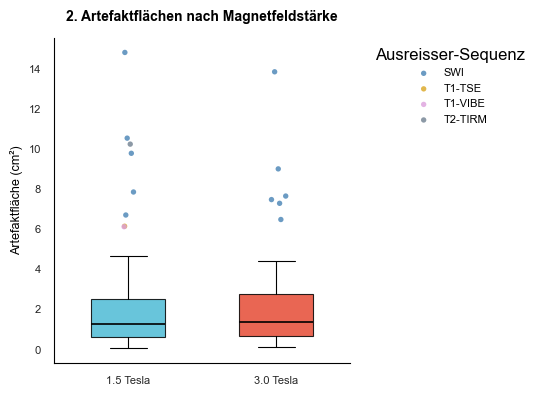


=== DATEN FÜR ABBILDUNG 2 (DESKRIPTIVE STATISTIK) ===
Feldstaerke  count     mean      std    min      25%      50%      75%     max
  1.5 Tesla   70.0 2.190066 2.832636 0.0756 0.629262 1.261275 2.532267 14.8104
  3.0 Tesla   70.0 2.219419 2.391838 0.1403 0.684375 1.357417 2.755175 13.8458

[ERGEBNIS] Grafik gespeichert unter: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/2_Gesamt_Feldstaerke.pdf
[ERGEBNIS] Statistik-Tabelle gespeichert unter: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/2_Gesamt_Feldstaerke_Statistik.csv


In [8]:
# =============================================================================
# VISUALISIERUNG 2: GESAMT-ARTEFAKTGRÖSSE NACH FELDSTÄRKE & DATEN-OUTPUT
# =============================================================================

# 1. Daten vorbereiten: Nur Proben mit Artefakten (> 0) betrachten
df_artifacts = df_summary[df_summary['Artefakt_flaeche_Mean'] > 0].copy()

# 2. Plot erstellen - MEHR BREITE HIER (5.5 statt 3.5)
fig, ax = plt.subplots(figsize=(5.5, 4))

bplot = ax.boxplot(
    [df_artifacts[df_artifacts['Feldstaerke'] == '1.5 Tesla']['Artefakt_flaeche_Mean'],
     df_artifacts[df_artifacts['Feldstaerke'] == '3.0 Tesla']['Artefakt_flaeche_Mean']],
    positions=[1, 2],         # Position 1 und 2
    patch_artist=True,
    widths=0.5,
    showfliers=False,         # WICHTIG: Versteckt die schwarzen Ausreisser
    medianprops=dict(color="black", linewidth=1.2)
)

# Farben und Styling der Boxen
for patch, color in zip(bplot['boxes'], [colors['1.5T'], colors['3.0T']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)

# Styling der Whiskers und Caps
for whisker in bplot['whiskers']: whisker.set(color='black', linewidth=0.8)
for cap in bplot['caps']: cap.set(color='black', linewidth=0.8)

# =============================================================================
# AUSREISSER BERECHNEN UND MIT MATPLOTLIB ZEICHNEN
# =============================================================================
outliers_df2 = get_outliers(df_artifacts, cat_col='Feldstaerke', val_col='Artefakt_flaeche_Mean')

kategorien = ['1.5 Tesla', '3.0 Tesla']

if not outliers_df2.empty:
    for i, category in enumerate(kategorien, start=1):
        cat_data = outliers_df2[outliers_df2['Feldstaerke'] == category]

        for mode in cat_data['Mode'].unique():
            y_vals = cat_data[cat_data['Mode'] == mode]['Artefakt_flaeche_Mean']
            x_vals = np.random.normal(loc=i, scale=0.04, size=len(y_vals))

            ax.scatter(x_vals, y_vals, color=color_map[mode], s=15, alpha=0.8,
                       label=mode, edgecolor='none')

    # Legende filtern und rechts aussen platzieren
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1),
                  loc='upper left', title="Ausreisser-Sequenz", frameon=False)

# Achsenbeschriftung und Titel
ax.set_xticks([1, 2])
ax.set_xticklabels(['1.5 Tesla', '3.0 Tesla'])

# WICHTIG: Verhindert das Quetschen (gibt Luft nach links und rechts)
ax.set_xlim(0.5, 2.5)

ax.set_ylabel('Artefaktfläche (cm²)')
ax.set_title('2. Artefaktflächen nach Magnetfeldstärke', fontweight='bold', pad=12)

# Achsen-Styling (Nature Style)
style_axes(ax)

# 3. Export und Anzeige der Grafik
plt.tight_layout()
plot_path_2 = os.path.join(out_dir_result, '2_Gesamt_Feldstaerke.pdf')
plt.savefig(plot_path_2, facecolor='white', transparent=False, dpi=300)
plt.show()

# =============================================================================
# PANDAS OUTPUT: STATISTIK FÜR ABBILDUNG 2
# =============================================================================

# Berechnung der relevanten statistischen Kennzahlen
stats_2 = df_artifacts.groupby('Feldstaerke')['Artefakt_flaeche_Mean'].describe().reset_index()

print("\n=== DATEN FÜR ABBILDUNG 2 (DESKRIPTIVE STATISTIK) ===")
# Zeigt Anzahl, Mittelwert, Std, Min, Median (50%) und Max
print(stats_2.to_string(index=False))

# Speichert die Statistik-Tabelle als CSV
csv_path_2 = os.path.join(out_dir_result, '2_Gesamt_Feldstaerke_Statistik.csv')
stats_2.to_csv(csv_path_2, index=False, sep=',', encoding="utf-8-sig")

print(f"\n[ERGEBNIS] Grafik gespeichert unter: {plot_path_2}")
print(f"[ERGEBNIS] Statistik-Tabelle gespeichert unter: {csv_path_2}")

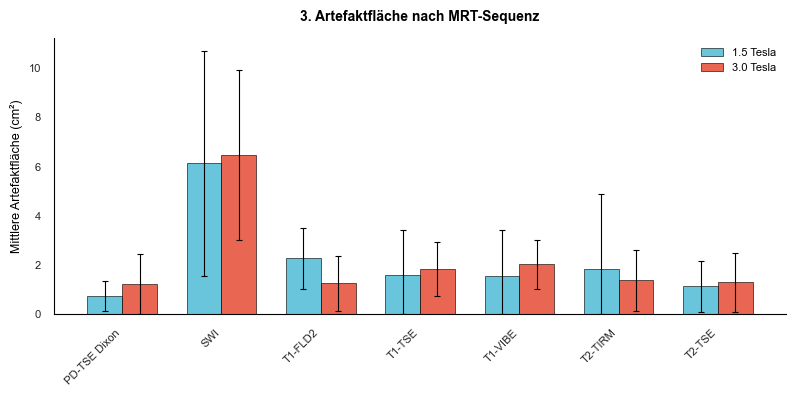


=== DATEN FÜR ABBILDUNG 3 (SEQUENZ-VERGLEICH) ===
Feldstaerke         Mode     mean      std
  1.5 Tesla PD-TSE Dixon 0.763072 0.607684
  1.5 Tesla          SWI 6.140252 4.564569
  1.5 Tesla      T1-FLD2 2.286090 1.240161
  1.5 Tesla       T1-TSE 1.595437 1.813958
  1.5 Tesla      T1-VIBE 1.578035 1.837127
  1.5 Tesla      T2-TIRM 1.830440 3.044798
  1.5 Tesla       T2-TSE 1.137137 1.020781
  3.0 Tesla PD-TSE Dixon 1.240440 1.220551
  3.0 Tesla          SWI 6.473655 3.443713
  3.0 Tesla      T1-FLD2 1.267298 1.110103
  3.0 Tesla       T1-TSE 1.831988 1.092804
  3.0 Tesla      T1-VIBE 2.044208 0.995195
  3.0 Tesla      T2-TIRM 1.380177 1.248589
  3.0 Tesla       T2-TSE 1.298167 1.194653

[ERGEBNIS] Grafik gespeichert unter: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/3_Sequenz_Vergleich.pdf
[ERGEBNIS] Quelldaten gespeichert unter: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/3_Sequenz_Vergleich_Daten.csv


In [9]:
# =============================================================================
# VISUALISIERUNG 3: ARTEFAKTFLÄCHE NACH MRT-SEQUENZ & DATEN-OUTPUT
# =============================================================================

# 1. Daten filtern und aggregieren
# Wir betrachten nur Proben, die Artefakte verursacht haben (> 0), um die
# Standardabweichung nicht durch Nullwerte zu verzerren.
df_artifacts = df_summary[df_summary['Artefakt_flaeche_Mean'] > 0].copy()

# Berechnung von Mittelwert und Standardabweichung pro Feldstärke und Sequenz (Mode)
seq_agg = df_artifacts.groupby(['Feldstaerke', 'Mode'])['Artefakt_flaeche_Mean'].agg(['mean', 'std']).reset_index()

# Konfiguration der X-Achse
modes = sorted(df_summary['Mode'].unique())
x = np.arange(len(modes))
width = 0.35

# 2. Plot erstellen
fig, ax = plt.subplots(figsize=(8, 4))

for i, fs in enumerate(['1.5 Tesla', '3.0 Tesla']):
    fs_data = seq_agg[seq_agg['Feldstaerke'] == fs]

    # Daten-Arrays für Mittelwerte und Fehler füllen
    means = np.array([fs_data[fs_data['Mode'] == m]['mean'].values[0] if m in fs_data['Mode'].values else 0 for m in modes])
    stds = np.array([fs_data[fs_data['Mode'] == m]['std'].values[0] if m in fs_data['Mode'].values else 0 for m in modes])

    # Bereinigung: NaN-Werte (bei nur einer Messung) durch 0 ersetzen
    stds = np.nan_to_num(stds)

    # Asymmetrische Fehlerbalken (verhindert, dass Fehler unter 0 cm² ragen)
    lower_errors = np.minimum(means, stds)
    upper_errors = stds
    yerr = [lower_errors, upper_errors]

    # Positionierung und Farbzuweisung
    offset = -width/2 if i == 0 else width/2
    color = colors['1.5T'] if fs == '1.5 Tesla' else colors['3.0T']

    # Zeichnen der Balken
    ax.bar(x + offset, means, width, yerr=yerr, label=fs, color=color,
           alpha=0.85, capsize=2, edgecolor='black', linewidth=0.5,
           error_kw=dict(lw=0.8, capthick=0.8, ecolor='black'))

# 3. Formatierung und Styling
ax.set_xticks(x)
ax.set_xticklabels(modes, rotation=45, ha='right')
ax.set_ylabel('Mittlere Artefaktfläche (cm²)')
ax.set_title('3. Artefaktfläche nach MRT-Sequenz', fontweight='bold', pad=12)

# Anwendung der einheitlichen Achsen-Styling-Funktion
style_axes(ax)
ax.legend(frameon=False)

# 4. Grafik speichern und anzeigen
plt.tight_layout()
plot_path_3 = os.path.join(out_dir_result, '3_Sequenz_Vergleich.pdf')
plt.savefig(plot_path_3, facecolor='white', transparent=False, dpi=300)
plt.show()

# =============================================================================
# PANDAS OUTPUT: EXPORT DER DATEN FÜR ABBILDUNG 3
# =============================================================================

# Zeigt die Tabelle direkt im Notebook an
print("\n=== DATEN FÜR ABBILDUNG 3 (SEQUENZ-VERGLEICH) ===")
# Wir zeigen die Tabelle ohne Index für bessere Lesbarkeit
print(seq_agg.to_string(index=False))

# Speichert die Tabelle zusätzlich als CSV in deinem Resultate-Ordner
csv_path_3 = os.path.join(out_dir_result, '3_Sequenz_Vergleich_Daten.csv')
seq_agg.to_csv(
    csv_path_3,
    index=False,
    sep=',',
    encoding="utf-8-sig"
)

print(f"\n[ERGEBNIS] Grafik gespeichert unter: {plot_path_3}")
print(f"[ERGEBNIS] Quelldaten gespeichert unter: {csv_path_3}")

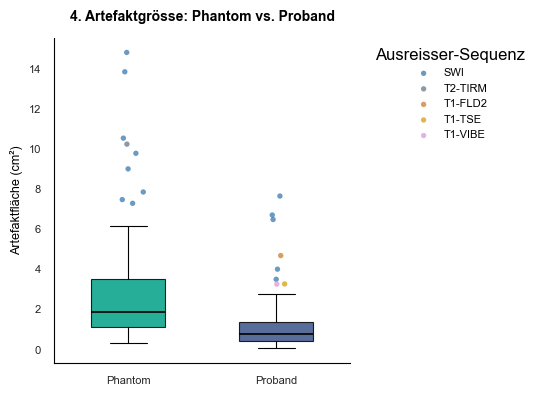


=== DATEN FÜR ABBILDUNG 4 (PHANTOM VS. PROBAND) ===
 Objekt  count     mean      std    min      25%      50%      75%     max
Phantom   70.0 3.058913 3.129878 0.3303 1.124675 1.867617 3.541375 14.8104
Proband   70.0 1.350572 1.571196 0.0756 0.411100 0.758475 1.390838  7.6518

[ERGEBNIS] Grafik gespeichert unter: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/4_Phantom_vs_Proband.pdf
[ERGEBNIS] Statistik-Tabelle erfolgreich gespeichert unter: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/4_Phantom_vs_Proband_Daten.csv


In [12]:
# =============================================================================
# VISUALISIERUNG 4: ARTEFAKTGRÖSSE PHANTOM VS. PROBAND & DATEN-OUTPUT
# =============================================================================

# 1. Daten vorbereiten
df_art_only = df_summary[df_summary['Artefakt_flaeche_Mean'] > 0].copy()

# 2. Plot erstellen
fig, ax = plt.subplots(figsize=(5.5, 4))

bplot = ax.boxplot(
    [df_art_only[df_art_only['Objekt'] == 'Phantom']['Artefakt_flaeche_Mean'],
     df_art_only[df_art_only['Objekt'] == 'Proband']['Artefakt_flaeche_Mean']],
    positions=[1, 2],
    patch_artist=True,
    widths=0.5,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.2)
)

# Farben und Styling der Boxen (Phantom vs. Proband)
for patch, color in zip(bplot['boxes'], [colors['Phantom'], colors['Proband']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)

# Styling der Whiskers und Caps
for whisker in bplot['whiskers']: whisker.set(color='black', linewidth=0.8)
for cap in bplot['caps']: cap.set(color='black', linewidth=0.8)

# =============================================================================
# AUSREISSER BERECHNEN UND MIT MATPLOTLIB ZEICHNEN
# =============================================================================
outliers_df4 = get_outliers(df_art_only, cat_col='Objekt', val_col='Artefakt_flaeche_Mean')

kategorien = ['Phantom', 'Proband']

if not outliers_df4.empty:
    for i, category in enumerate(kategorien, start=1):
        cat_data = outliers_df4[outliers_df4['Objekt'] == category]

        for mode in cat_data['Mode'].unique():
            y_vals = cat_data[cat_data['Mode'] == mode]['Artefakt_flaeche_Mean']
            x_vals = np.random.normal(loc=i, scale=0.04, size=len(y_vals))

            ax.scatter(x_vals, y_vals, color=color_map[mode], s=15, alpha=0.8,
                       label=mode, edgecolor='none')

    # --- FILTERUNG FÜR EINE UNIQUE LEGENDE ---
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles)) # Entfernt Duplikate automatisch

    ax.legend(by_label.values(), by_label.keys(),
              bbox_to_anchor=(1.05, 1), loc='upper left',
              title="Ausreisser-Sequenz", frameon=False)

# Achsenbeschriftung und Titel
ax.set_xticks([1, 2])
ax.set_xticklabels(['Phantom', 'Proband'])
ax.set_xlim(0.5, 2.5)
ax.set_ylabel('Artefaktfläche (cm²)')
ax.set_title('4. Artefaktgrösse: Phantom vs. Proband', fontweight='bold', pad=12)

style_axes(ax)

# 3. Export und Anzeige der Grafik
plt.tight_layout()
plot_path_4 = os.path.join(out_dir_result, '4_Phantom_vs_Proband.pdf')
plt.savefig(plot_path_4, facecolor='white', transparent=False, dpi=300)
plt.show()

# =============================================================================
# PANDAS OUTPUT: STATISTIK FÜR ABBILDUNG 4
# =============================================================================

# Berechnung der relevanten statistischen Kennzahlen
objekt_agg = df_art_only.groupby('Objekt')['Artefakt_flaeche_Mean'].describe().reset_index()

# 1. Zeigt die Tabelle direkt im Notebook an
print("\n=== DATEN FÜR ABBILDUNG 4 (PHANTOM VS. PROBAND) ===")
print(objekt_agg.to_string(index=False))

# 2. Speichert die Statistik-Tabelle als CSV (Source Data)
csv_path_4 = os.path.join(out_dir_result, '4_Phantom_vs_Proband_Daten.csv')
objekt_agg.to_csv(csv_path_4, index=False, sep=',', encoding="utf-8-sig")

print(f"\n[ERGEBNIS] Grafik gespeichert unter: {plot_path_4}")
print(f"[ERGEBNIS] Statistik-Tabelle erfolgreich gespeichert unter: {csv_path_4}")

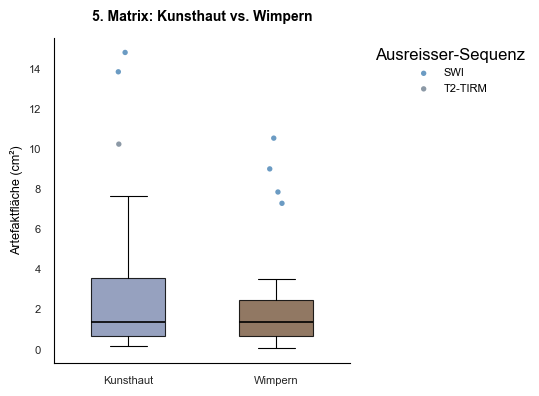


=== DATEN FÜR ABBILDUNG 5 (MATRIX-VERGLEICH) ===
  Traeger  count     mean      std    min      25%      50%      75%       max
Kunsthaut   56.0 2.589674 3.064738 0.1680 0.671062 1.361850 3.544650 14.810400
  Wimpern   56.0 1.944257 2.126157 0.0756 0.669875 1.390725 2.491433 10.538667

[ERGEBNIS] Grafik gespeichert unter: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/5_Wimpern_vs_Kunsthaut_Boxplot.pdf
[ERGEBNIS] Statistik-Tabelle gespeichert unter: /Users/lauracam/Library/CloudStorage/Dropbox/ETH/Muriel/Resultate/5_Wimpern_vs_Kunsthaut_Daten.csv


In [11]:
# =============================================================================
# VISUALISIERUNG 5: KUNSTHAUT VS. WIMPERN (MATRIX-VERGLEICH) & DATEN-OUTPUT
# =============================================================================

# 1. Daten vorbereiten
df_art_only = df_summary[df_summary['Artefakt_flaeche_Mean'] > 0].copy()

pigments_wimpern = set(df_art_only[df_art_only['Traeger'] == 'Wimpern']['Farbe_ID'])
pigments_kunsthaut = set(df_art_only[df_art_only['Traeger'] == 'Kunsthaut']['Farbe_ID'])
overlap_pigments = list(pigments_wimpern.intersection(pigments_kunsthaut))

df_overlap = df_art_only[df_art_only['Farbe_ID'].isin(overlap_pigments)].copy()

data_kunsthaut = df_overlap[df_overlap['Traeger'] == 'Kunsthaut']['Artefakt_flaeche_Mean']
data_wimpern = df_overlap[df_overlap['Traeger'] == 'Wimpern']['Artefakt_flaeche_Mean']

# 2. Plot erstellen
fig, ax = plt.subplots(figsize=(5.5, 4))

bplot = ax.boxplot(
    [data_kunsthaut, data_wimpern],
    positions=[1, 2],
    patch_artist=True,
    widths=0.5,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.2)
)

# Farben und Styling der Boxen (Kunsthaut vs. Wimpern)
for patch, color in zip(bplot['boxes'], [colors['Kunsthaut'], colors['Wimpern']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)

# Styling der Whiskers und Caps
for whisker in bplot['whiskers']: whisker.set(color='black', linewidth=0.8)
for cap in bplot['caps']: cap.set(color='black', linewidth=0.8)

# =============================================================================
# AUSREISSER BERECHNEN UND MIT MATPLOTLIB ZEICHNEN
# =============================================================================
outliers_df5 = get_outliers(df_overlap, cat_col='Traeger', val_col='Artefakt_flaeche_Mean')

kategorien = ['Kunsthaut', 'Wimpern']

if not outliers_df5.empty:
    for i, category in enumerate(kategorien, start=1):
        cat_data = outliers_df5[outliers_df5['Traeger'] == category]

        for mode in cat_data['Mode'].unique():
            y_vals = cat_data[cat_data['Mode'] == mode]['Artefakt_flaeche_Mean']
            x_vals = np.random.normal(loc=i, scale=0.04, size=len(y_vals))

            ax.scatter(x_vals, y_vals, color=color_map[mode], s=15, alpha=0.8,
                       label=mode, edgecolor='none')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if by_label:
        ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1),
                  loc='upper left', title="Ausreisser-Sequenz", frameon=False)

# Achsenbeschriftung und Titel
ax.set_xticks([1, 2])
ax.set_xticklabels(['Kunsthaut', 'Wimpern'])
ax.set_xlim(0.5, 2.5)
ax.set_ylabel('Artefaktfläche (cm²)')
ax.set_title('5. Matrix: Kunsthaut vs. Wimpern', fontweight='bold', pad=12)

style_axes(ax)

# 3. Export und Anzeige der Grafik
plt.tight_layout()
plot_path_5 = os.path.join(out_dir_result, '5_Wimpern_vs_Kunsthaut_Boxplot.pdf')
plt.savefig(plot_path_5, facecolor='white', transparent=False, dpi=300)
plt.show()

# =============================================================================
# PANDAS OUTPUT: STATISTIK FÜR ABBILDUNG 5
# =============================================================================

# Berechnung der statistischen Kennzahlen für den Matrix-Vergleich
traeger_agg = df_overlap.groupby('Traeger')['Artefakt_flaeche_Mean'].describe().reset_index()

# Zeigt die Tabelle direkt im Notebook an
print("\n=== DATEN FÜR ABBILDUNG 5 (MATRIX-VERGLEICH) ===")
print(traeger_agg.to_string(index=False))

# Speichert die Statistik-Tabelle als CSV (Source Data)
csv_path_5 = os.path.join(out_dir_result, '5_Wimpern_vs_Kunsthaut_Daten.csv')
traeger_agg.to_csv(csv_path_5, index=False, sep=',', encoding="utf-8-sig")

print(f"\n[ERGEBNIS] Grafik gespeichert unter: {plot_path_5}")
print(f"[ERGEBNIS] Statistik-Tabelle gespeichert unter: {csv_path_5}")